# Advanced Models

Up to now, we’ve focused on binary classification with a pereceptron and MLP. This week, we’ll expand our toolkit so our models can handle different types of problems and become more robust. Real world problems rarely fit neatly into “yes/no” binary outputs. By the end of this week, you’ll know how to:

- Train models that classify among many categories
- Predict continuous values
- Control overfitting
- Validate models more effectively

## Multi Class Classification

So far, we’ve focused on binary classification: predicting between two classes using Sigmoid activation and BCE loss. But what if we have more than two categories, like classifying handwritten characters or identifying which of animal appears in an image? This requires a multi class classification setup, where the model must decide between many possible labels. To do this, we replace the binary tools (Sigmoid + BCE) with functions designed for multi class problems (Softmax and CrossEntropyLoss).

### Multi Class Final Layer

Softmax is used in multi class classification. Instead of outputting just one score, the model gives a score for each possible class. Softmax turns those scores into probabilities that are easy to read (between 0 and 1) and add up to 1 across all classes. This way, we can say: “The model thinks Class A has a 70% chance, Class B has a 20% chance, and Class C has a 10% chance.” Think of the model as “voting” for each class.

In [ ]:
import torch.nn as nn

class MultiClassMLP(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
      super().__init__()
      
      self.hidden = nn.Linear(input_size, hidden_size)
      self.relu = nn.ReLU()
      
      self.output = nn.Linear(hidden_size, num_classes)
      self.log_softmax = nn.LogSoftmax(dim=1)

  def forward(self, x):
      x = self.hidden(x)
      x = self.relu(x)
      
      x = self.output(x)
      return self.log_softmax(x)


## Regression

So far, we’ve used neural networks for classification problems, predicting discrete categories like “authentic vs. counterfeit” or “cat vs. dog vs. horse.” But many real world tasks are regression problems, where the goal is to predict a continuous value instead of a class e.g. predicting the price of a house, estimating the temperature tomorrow, predicting a student’s final grade from study hours.

### Regression Final Layer

In classification tasks, we used activations like Sigmoid (binary) or Softmax (multi class) to turn the model’s raw outputs into probabilities. For regression, we don’t want probabilities, we want a raw number. That means the final layer should be a Linear layer with just one output neuron, no activation function is applied to this final output.

In [124]:
import torch.nn as nn

class RegressionMLP(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        
        self.hidden = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        
        x = self.output(x)
        return x

## Model Differences

Different tasks require slightly different choices for the final layer, the activation function, and the loss function. It’s important to match these pieces correctly so the network’s outputs make sense and the loss can guide learning.

| Task Type                      | Final Layer Output                                              | Final Layer Activation                                     | Loss Function                                                          | How to Predict                                               |
| ------------------------------ | --------------------------------------------------------------- | ------------------------------------------------------- | ---------------------------------------------------------------------- | ------------------------------------------------------------ |
| **Binary Classification**      | 1 output neuron                                                 | **Sigmoid** (gives probability 0–1)                     | `BCELoss` (requires Sigmoid) OR `BCEWithLogitsLoss` (built in Sigmoid) | Apply threshold|
| **Multi Class Classification** | 1 output neuron **per class** | **Softmax** (probabilities across all classes, sum = 1) | `NLLLoss` (requires Softmax) OR `CrossEntropyLoss` (built in Softmax)                                  | `torch.argmax`|
| **Regression** | 1 output neuron **per output** |  Raw number (no activation) | `nn.MSELoss()` | Use output directly |


## Regularization

Neural networks are powerful, but that also means they can easily overfit, memorizing the training data instead of learning patterns that generalize to new data.
Regularization refers to techniques that reduce overfitting by making models more robust. In practice, this means adding a little “friction” to training so the network doesn’t lean too heavily on any one neuron or weight. There are many types of regularization, but we’ll focus on two of the most common: Dropout and Batch Normalization.

### Dropout

Dropout is one of the simplest and most effective ways to regularize a neural network. During training, dropout works by randomly turning off some neurons in a layer on each forward pass. Those neurons don’t contribute for that batch, and on the next batch a different set may be dropped. This randomness forces the network to spread learning across many connections instead of memorizing a single path. In other words, dropout helps the model learn features that generalize better. During inference we disable this layer so all neurons are active.

Placement: usually added after the activation in hidden layers (not on inputs or outputs).

### BatchNorm

As data flows through a network, the raw values going into each activation can drift, sometimes getting very large, sometimes very small. This can slow down or destabilize training. Batch Normalization fixes this by normalizing those values within each batch so they have a more stable mean and variance. The effect of this is that training is more stable (gradients are less likely to get extrmely small or extremely large). Also, models often converge faster, this means we can train in fewer epochs. During inference we also need to adjust this layer, though it is not totally disabled like Dropout.

Placement: usually used right after a linear layer, before the activation.

In [125]:
import torch.nn as nn

class RegressionMLP(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_rate=0.5):
        super().__init__()
        
        self.hidden = nn.Linear(input_size, hidden_size)
        self.batchnorm = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.batchnorm(x)
        x = self.relu(x)
        x = self.dropout(x)
                
        x = self.output(x)
        
        return x


## Validation

We’ve already seen how to split data into train and test sets, and how overfitting shows up as strong training performance but weaker test performance. The new challenge is that some layers in our models, like **Dropout** and **BatchNorm**, behave differently during training and evaluation. That means we need to tell PyTorch explicitly which mode we’re in. We did this already when we disabled gradient tracking for inference in week 2, we just need to expand this idea for our new layer types.

### Training vs Evaluation Modes

In training mode, layers such as Dropout and Batch Normalization must remain active so the model can learn effectively. We want dropout to randomly disables neurons to reduce overfitting, and batch normalization normalizes activations using statistics from the current batch. We enable this behavior with:

`model.train()`

When the model is being evaluated or used for inference, these layers should behave differently. Dropout is disabled so all neurons contribute to the prediction, and batch normalization uses the running averages collected during training. We enable this using:

`model.eval()`

### Validation During Training

So far, we’ve trained models for a fixed number of epochs and only checked performance at the end. A better practice is to **track validation performance during training**.  

- Training loss will almost always keep dropping as the model memorizes the data.  
- Validation loss, on the other hand, tells us if the model is truly **generalizing**.  
- By looking at **training vs. validation curves together**, we can spot when the model starts to **overfit**.  

This is why we split each epoch into two phases:  
1. **Training phase** - train model with train data, update weights with backpropagation
2. **Validation phase** - evaluate the model with test data, without updating weights  

This gives us both training and validation loss at the end of each epoch, so we can see how the model evolves.

### Randomness and Reproducibility

When you run the same training loop more than once, the results may not be identical. This is because neural networks use randomness in several places.

- Weight initialization: model weights start from random values
- Dropout: randomly disables neurons while training

This randomness is important for learning, but it also means results can vary from run to run. To make results consistent, for debugging, comparing models, or training, we set a random seed so the “random” choices follow the same sequence every time. In practice, we only need to control randomness during training. Once a model is trained and in inference mode, predictions are deterministic, so seeds are not needed.

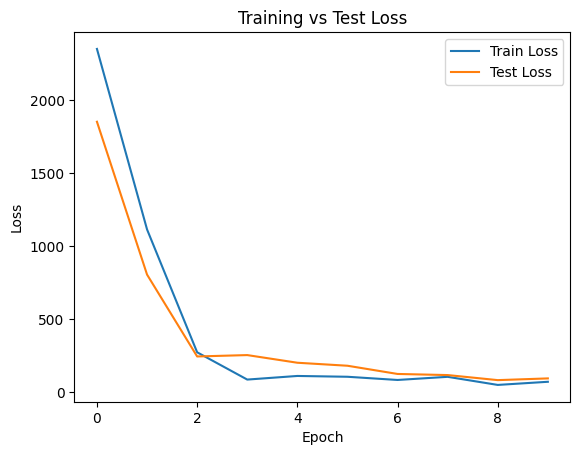

In [ ]:
import random
import torch
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# control randomness while training
SEED = 1122
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

X, y = make_regression(n_samples=200, n_features=2, random_state=SEED, noise=0.2, coef=False) # type: ignore
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float().view(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=SEED)

model = RegressionMLP(input_size=2, hidden_size=128)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

n_epochs = 10
train_losses = []
test_losses = []
for epoch in range(n_epochs):
    # ----- Training -----
    model.train()                                # set to training mode
    optimizer.zero_grad()
    outputs = model(X_train)
    train_loss = loss_fn(outputs, y_train)
    train_losses.append(train_loss.item())
    train_loss.backward()
    optimizer.step()

    # ----- Validation -----
    model.eval()                                 # set to eval mode
    with torch.no_grad():                        # disable gradient tracking
        test_outputs = model(X_test)
        test_loss = loss_fn(test_outputs, y_test)
        test_losses.append(test_loss.item())

# ----- Check fit -----
fig, ax = plt.subplots()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
ax.set(xlabel='Epoch', ylabel='Loss', title='Training vs Test Loss')
plt.legend()
plt.show()

When we plot training loss vs test loss across epochs, the shape of the curves tells us how well the model is learning:

- Good Fit: training loss decreases, test loss follows closely. The two curves stay close together
- Overfitting: training loss keeps going down, but test loss stops improving (or goes back up). A clear gap forms between the two curves
- Underfitting: both training and test losses stay high and don’t improve much. The model is too simple or hasn’t trained long enough

# Summary

This week we learned how different tasks require different final layers and loss functions. We also explored different techniques to help reduce overfitting, finally we expanded validation to track performance during training so we can compare training and validation losses per epoch.

## Model Types

- Binary Classification: Sigmoid + BCELoss, threshold for predictions
- Multi Class Classification: LogSoftmax + NLLLoss, torch.argmax for predictions
- Regression: Linear output + MSELoss, raw value for predictions

## Regularization

- Dropout: randomly turns off neurons during training to prevent reliance on a single path, disabled during inference
- Batch Normalization: normalizes activations within each batch to keep values stable, uses batch statistics during training, stored averages during inference

# Validation

- torch.no_grad(): disables gradient tracking to save memory and speed up evaluation
- model.train() / model.eval(): switches layer behavior between training and inference modes
- setting seeds to control reproducibility